#1 - Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import os, random, time, json

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [2]:
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

ACTIVITY_NAMES = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

N_CLASSES   = 6
N_TIMESTEPS = 128
N_CHANNELS  = 9

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (6249, 128, 9)
X_val:   (1103, 128, 9)
X_test:  (2947, 128, 9)
y_train: (6249,)
y_val:   (1103,)
y_test:  (2947,)


What LSTM adds over CNN:
The CNN learned local patterns — short bursts of motion within a few timesteps. But it has no memory of what happened earlier in the sequence. An LSTM reads the 128 timesteps one at a time, left to right, and maintains a hidden state that carries information forward. By timestep 128, the hidden state has been influenced by every timestep before it.


---


The gating mechanism:
LSTM has three gates — forget, input, and output. The forget gate decides what to erase from memory. The input gate decides what new information to write. The output gate decides what to pass forward as the hidden state. These gates are learned during training, not manually set.


---


What this means for HAR:
Walking has a rhythm that plays out over many timesteps. The LSTM can learn that "if the last 20 timesteps showed a periodic pattern, the next few will too." This is long-range temporal reasoning that Conv1D cannot do because its receptive field is limited to the kernel size.


---


The key question:
The CNN already achieved 99.46% validation accuracy by detecting local patterns alone. Does adding long-range memory improve the remaining errors — specifically Sitting vs Standing?

In [73]:
from keras import Input
from keras import Model

from keras.optimizers import Adam

from keras.layers import LSTM, BatchNormalization, Dropout, Dense, Activation

#2 - Build LSTM Model

In [187]:
def build_lstm(learning_rate=0.0005, dropout=0.3, unit_1=256, unit_2=128):

    inputs = Input(shape=(N_TIMESTEPS, N_CHANNELS))

    # First LSTM
    x = LSTM(unit_1, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    # Second LSTM
    x = LSTM(unit_2, return_sequences=False)(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    outputs = Dense(N_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name="lstm_model")
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate),
        metrics=['accuracy']
    )
    return model

In [188]:
lstm_model = build_lstm(
    learning_rate=0.0005,
    dropout=0.3,
    unit_1=512,
    unit_2=256
)

In [189]:
lstm_model.summary()

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 128, 512)       │     1,069,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 128, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_45 (LSTM)                  │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,861,126 (7.10 MB)

 Trainable params: 1,859,590 (7.09 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [190]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [191]:
checkpoint_cb = ModelCheckpoint(
    filepath='lstm_model.keras',
    monitor='val_loss',
    mode='min',                     # 'min' for loss, 'max' for accuracy
    save_best_only=True,            # Only save when performance improves
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

In [192]:
callbacks = [early_stopping_cb, reduce_lr_cb, checkpoint_cb]

#3 - Train LSTM

In [193]:
start_time = time.time()

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.1f} seconds")

Epoch 1/200
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7629 - loss: 0.6736
Epoch 1: val_loss improved from None to 0.86142, saving model to lstm_model.keras

Epoch 1: finished saving model to lstm_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.8539 - loss: 0.3999 - val_accuracy: 0.7262 - val_loss: 0.8614 - learning_rate: 5.0000e-04
Epoch 2/200
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9307 - loss: 0.1723
Epoch 2: val_loss improved from 0.86142 to 0.33098, saving model to lstm_model.keras

Epoch 2: finished saving model to lstm_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9310 - loss: 0.1736 - val_accuracy: 0.8758 - val_loss: 0.3310 - learning_rate: 5.0000e-04
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9387 - loss: 0.1523
Epoch 3: val_loss improved from 0.33098 to 0.14386, saving model to lstm_model.keras

Epoch 3: finished saving model to lstm_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accu

In [194]:
# Find the epoch with the lowest validation loss
best_epoch_index = np.argmin(history.history['val_loss'])

# Extract the metrics at that specific epoch
best_val_loss = history.history['val_loss'][best_epoch_index]
best_val_accuracy = history.history['val_accuracy'][best_epoch_index]

print("\n" + "="*40)
print(f"TRAINING COMPLETE - BEST METRICS FOUND:")
print(f"Best Epoch: {best_epoch_index + 1}") # +1 because epochs are 1-indexed in output but 0-indexed in arrays
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("="*40 + "\n")

# Verify the restored weights match by evaluating the model directly
print("Verifying restored weights on validation data:")
loss, acc = lstm_model.evaluate(X_val, y_val, verbose=0)
print(f"Evaluated Validation Loss: {loss:.4f}")
print(f"Evaluated Validation Accuracy: {acc:.4f}")


TRAINING COMPLETE - BEST METRICS FOUND:
Best Epoch: 73
Best Validation Loss: 0.0170
Best Validation Accuracy: 0.9937

Verifying restored weights on validation data:
Evaluated Validation Loss: 0.0170
Evaluated Validation Accuracy: 0.9937


TRAINING COMPLETE - BEST METRICS FOUND:

---


* Best Epoch: 73
* Best Validation Loss: 0.0170
* Best Validation Accuracy: 0.9937


---

#4 - Plot Comparisons

In [195]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

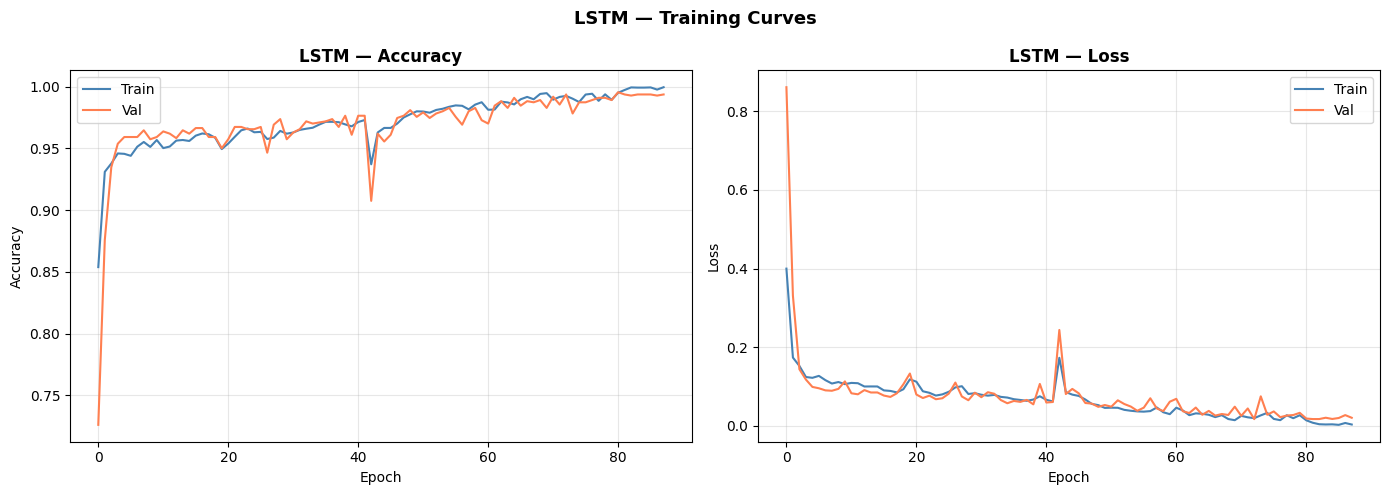

Best val_accuracy : 0.9955
Best val_loss     : 0.0170
Stopped at epoch  : 88


In [196]:
import os
# Ensure the directory exists before saving
os.makedirs('reports/figures/', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('LSTM — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='coral')
axes[1].set_title('LSTM — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f"Stopped at epoch  : {len(history.history['loss'])}")

In [197]:
y_pred_probs = lstm_model.predict(X_val)
y_pred       = np.argmax(y_pred_probs, axis=1)

val_accuracy = np.mean(y_pred == y_val)
val_f1_macro = f1_score(y_val, y_pred, average='macro')

print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Validation Macro F1 : {val_f1_macro:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=ACTIVITY_NAMES))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Validation Accuracy : 0.9937
Validation Macro F1 : 0.9942

                    precision    recall  f1-score   support

           Walking       1.00      1.00      1.00       184
  Walking Upstairs       1.00      1.00      1.00       161
Walking Downstairs       1.00      1.00      1.00       148
           Sitting       0.96      1.00      0.98       193
          Standing       1.00      0.97      0.98       206
            Laying       1.00      1.00      1.00       211

          accuracy                           0.99      1103
         macro avg       0.99      0.99      0.99      1103
      weighted avg       0.99      0.99      0.99      1103



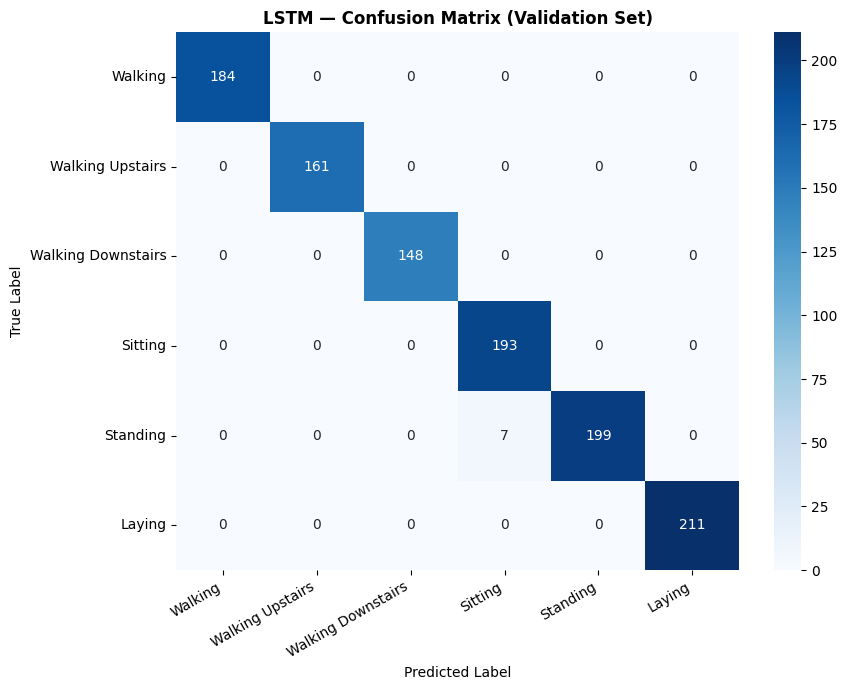

In [198]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITY_NAMES,
            yticklabels=ACTIVITY_NAMES)
plt.title('LSTM — Confusion Matrix (Validation Set)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [199]:
test_loss, test_acc = lstm_model.evaluate(X_test, y_test, verbose=1)

print(f"\n[Verification] Loaded Model Test Accuracy: {test_acc:.4f}")
print(f"[Verification] Loaded Model Test Loss:     {test_loss:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9515 - loss: 0.2065

[Verification] Loaded Model Test Accuracy: 0.9515
[Verification] Loaded Model Test Loss:     0.2065


#5 - Save Model

In [200]:
lstm_results = {
    "model"            : "LSTM_model",
    "architecture"     : "512→256 units, BN+Drop, lr=0.0005",
    "total_params"     : lstm_model.count_params(),
    "val_accuracy"     : round(float(val_accuracy), 4),
    "val_f1_macro"     : round(float(val_f1_macro), 4),
    "training_time"    : round(training_time, 1),
    "epochs_run"       : len(history.history['loss']),
    "best_epoch"       : 73,
    "train_acc_curve"  : [round(v, 4) for v in history.history['accuracy']],
    "val_acc_curve"    : [round(v, 4) for v in history.history['val_accuracy']],
    "train_loss_curve" : [round(v, 4) for v in history.history['loss']],
    "val_loss_curve"   : [round(v, 4) for v in history.history['val_loss']],
}

os.makedirs("artifacts/results", exist_ok=True)
with open("artifacts/results/lstm_results.json", "w") as f:
    json.dump(lstm_results, f, indent=2)

print("Results saved to artifacts/results/lstm_results.json")
print()
print("=" * 45)
print("LSTM FINAL SUMMARY")
print("=" * 45)
print(f"Architecture     : 512→256 units")
print(f"Total Parameters : {lstm_model.count_params():,}")
print(f"Val Accuracy     : {val_accuracy:.4f}")
print(f"Val Macro F1     : {val_f1_macro:.4f}")
print(f"Training Time    : {training_time:.1f}s")
print(f"Epochs Run       : {len(history.history['loss'])}")
print(f"Best Epoch       : 73")
print("=" * 45)

Results saved to artifacts/results/lstm_results.json

LSTM FINAL SUMMARY
Architecture     : 512→256 units
Total Parameters : 1,861,126
Val Accuracy     : 0.9937
Val Macro F1     : 0.9942
Training Time    : 479.4s
Epochs Run       : 88
Best Epoch       : 73


In [201]:
os.makedirs("artifacts/models", exist_ok=True)
lstm_model.save("artifacts/models/lstm_best.keras")
print("Model saved to artifacts/models/lstm_best.keras")

Model saved to artifacts/models/lstm_best.keras


In [203]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('artifacts/models/lstm_best.keras')

# Evaluate on test data to verify
test_loss, test_acc = loaded_model.evaluate(X_test, y_test, verbose=1)

print(f"\n[Verification] Loaded Model Test Accuracy: {test_acc:.4f}")
print(f"[Verification] Loaded Model Test Loss:     {test_loss:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9515 - loss: 0.2065

[Verification] Loaded Model Test Accuracy: 0.9515
[Verification] Loaded Model Test Loss:     0.2065


LSTM — Architecture  : 512→256, BN+Drop, lr=0.0005


---


LSTM — Parameters    : 1,861,126


---


LSTM — Val Accuracy  : 99.37%


---


LSTM — Macro F1      : 99.42%


---


LSTM — Training Time : 479.4 seconds (8 minutes)


---


LSTM — Best Epoch    : 73


---



Key Finding:
* CNN outperformed LSTM despite having 14.6x fewer parameters.
The UCI HAR dataset's discriminative features are local temporal
patterns (step rhythms, motion signatures) rather than long-range
sequential dependencies. This makes CNN architecturally better
suited to the problem than LSTM.

* LSTM only matched CNN performance by scaling to 1.86M parameters —
an inefficient use of capacity for this dataset.